## 1. Google Play Store apps and reviews
<p>Las aplicaciones móviles están en todas partes. Son fáciles de crear y pueden resultar muy lucrativas. Debido a estos dos factores, se están desarrollando cada vez más aplicaciones. En este ejercicio, haremos un análisis completo del mercado de aplicaciones de Android comparando más de diez mil aplicaciones en Google Play en diferentes categorías. Buscaremos información valiosa en los datos para diseñar estrategias que impulsen el crecimiento y la retención.</p>
<p><img src="https://assets.datacamp.com/production/project_619/img/google_play_store.png" alt="Google Play logo"></p>
<p>Tenemos dos fuentes de datos:</p>
<ul>
<li><code>apps.csv</code>: contiene todos los detalles de las aplicaciones en Google Play. Hay 13 características que describen una aplicación determinada.</li>
<li><code>user_reviews.csv</code>: contiene 100 reseñas para cada aplicación, <a href="https://www.androidpolice.com/2019/01/21/google-play-stores-redesigned-ratings-and-reviews-section-lets-you-easily-filter-by-star-rating/">reviews</a>. El texto de cada reseña se ha procesado previamente y se le atribuyen tres características nuevas: Sentimiento (positivo, negativo o neutral), Polaridad del sentimiento y Subjetividad del sentimiento..</li>
</ul>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Importa el dataset apps.csv
apps = pd.read_csv(r'C:\Users\Rod Cissan\EBAC DATA SCY\Avance Proyecto\Part1\apps.csv')

# Borra todos los duplicados del dataset
apps = apps.drop_duplicates()

# Imprime el total de apps que se van a analizar que quedan (dimensión)
print('Total number of apps in the dataset = ', apps.shape)

# Imprime la estadística descriptiva de resumen
print(apps.describe())

# Vamos a echar un vistazo al DataFrame final
print(apps.head())


Total number of apps in the dataset =  (9659, 13)
            Rating       Reviews         Size
count  8196.000000  9.659000e+03  8432.000000
mean      4.173243  2.165926e+05    20.395327
std       0.536625  1.831320e+06    21.827509
min       1.000000  0.000000e+00     0.000000
25%       4.000000  2.500000e+01     4.600000
50%       4.300000  9.670000e+02    12.000000
75%       4.500000  2.940100e+04    28.000000
max       5.000000  7.815831e+07   100.000000
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

   Reviews  Size     Installs  Type Price Content Ratin

## 2. Data cleaning
<p>Las cuatro variables con las que trabajaremos con más frecuencia de ahora en adelante son <i>Installs</i>, <i>Size</i>, <i>Rating</i> y <i>Price</i>. La función <code>info()</code> nos dice que las columnas <i>Installs</i> y <i>Price</i> son de tipo <code>object</code>, no son de tipo <code>int</code> o <code>float</code> como esperaríamos. Esto se debe a que la columna contiene algunos caracteres más que solo [0,9] dígitos. Idealmente, queremos que estas columnas fueran puramente numéricas<br>
<br>
Por lo tanto, ahora necesitamos limpiar nuestros datos. Específicamente, los caracteres especiales <code>,</code> y <code>+</code> que se encuentran en la columna <i>Installs</i> y <code>$</code> que esta en la columna <i>Price</i>.</p>

<p>Aquí un link donde podrás ver un poco más a detalle que es una <a href="https://www.freecodecamp.org/espanol/news/expresiones-lambda-en-python/">función lambda</a>

In [3]:
# Lista de caracteres a eliminar
chars_to_remove = [',', '+', '$']
# Lista de las columnas a limpiar
cols_to_clean = ['Installs', 'Price']

# Loop para cada columna
for col in cols_to_clean:
    # Loop para cada caracter especial
    for char in chars_to_remove:
        # Reemplaza con una función lambda el caracter especial por un texto vacío ('')
        apps[col] = apps[col].apply(lambda x: str(x).replace(char, ''))
    # Convierte la columna a tipo flotante (float)
    apps[col] = apps[col].astype(float)

# Imprime el total de apps que se van a analizar que quedan (dimensión)
print('Total number of apps in the dataset = ', apps.shape)

# Imprime la estadística descriptiva de resumen
print(apps.describe())

# Vamos a echar un vistazo al DataFrame final
print(apps.head())


Total number of apps in the dataset =  (9659, 13)
            Rating       Reviews         Size      Installs        Price
count  8196.000000  9.659000e+03  8432.000000  9.659000e+03  9659.000000
mean      4.173243  2.165926e+05    20.395327  7.777507e+06     1.099299
std       0.536625  1.831320e+06    21.827509  5.375828e+07    16.852152
min       1.000000  0.000000e+00     0.000000  0.000000e+00     0.000000
25%       4.000000  2.500000e+01     4.600000  1.000000e+03     0.000000
50%       4.300000  9.670000e+02    12.000000  1.000000e+05     0.000000
75%       4.500000  2.940100e+04    28.000000  1.000000e+06     0.000000
max       5.000000  7.815831e+07   100.000000  1.000000e+09   400.000000
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ... 

## 3. Exploring App's categories
<p>Con más de mil millones de usuarios activos en 190 países de todo el mundo, Google Play sigue siendo una importante plataforma de distribución para crear una audiencia global. Para que las empresas muestren sus aplicaciones a los usuarios, es importante hacerlas más rápida y fácilmente visibles en Google Play. Para mejorar la experiencia de búsqueda general, Google ha introducido el concepto de agrupar aplicaciones en categorías.</p>
<p>Esto nos lleva a las siguientes preguntas:</p>
<ul>
<li>¿Qué categoría tiene la mayor participación de aplicaciones (activas) en el mercado?</li>
<li>¿Alguna categoría específica domina el mercado?</li>
<li>¿Qué categorías tienen la menor cantidad de aplicaciones?</li>
</ul>
<p>Vamos a responder estas preguntas aquí <code>33</code> categorías unicas estan presentas en nuestro dataset. Las apps de <em>Family</em> y <em>Game</em> tienen la mayor prevalencia del mercado. Curiosamente, <em>Tools</em>, <em>Business</em> y <em>Medical</em> también están en el top.</p>

Number of categories =  33


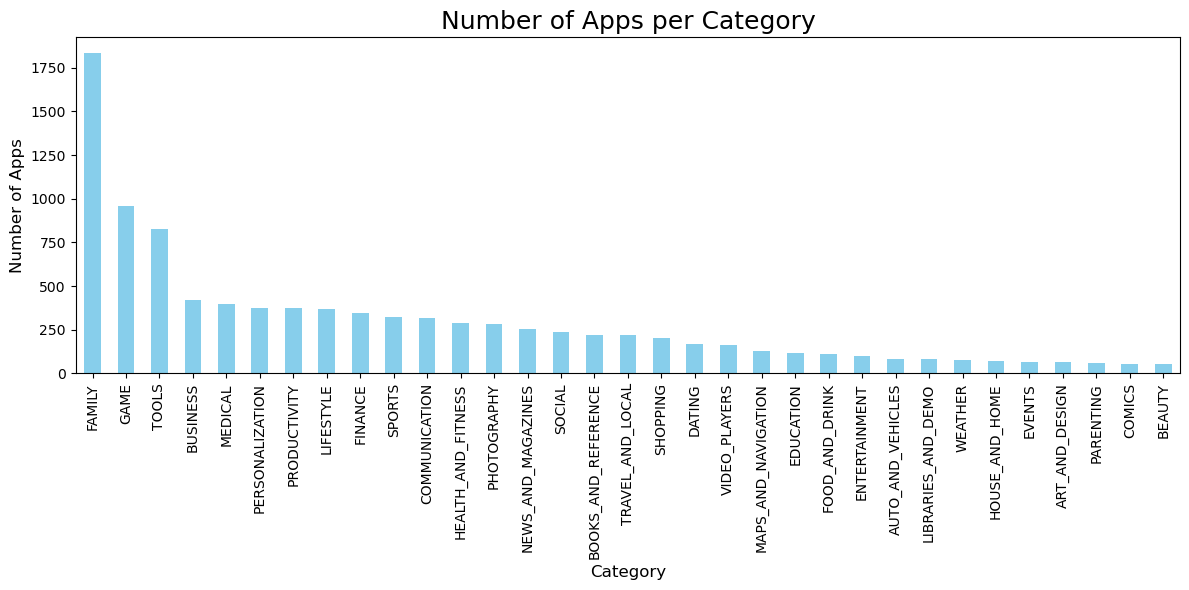

In [15]:
# Imprime el total de categorías únicas
num_categories = apps['Category'].nunique()
print('Number of categories = ', num_categories)

# Cuenta el número de aplicaciones en cada Categoría y ordena de manera descendente 
num_apps_in_category = apps['Category'].value_counts().sort_values(ascending=False)

# Muestra el resultado en una gráfica de barras
num_apps_in_category.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Number of Apps per Category', fontsize=18)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Ratings Distribution
<p>Después de analizar la participación de mercado para cada categoría de las aplicaciones, veamos cómo se posicionan de acuerdo a las calificaciones (en una escala del 1 al 5) las cuales afectan la imagen de la marca general de la empresa. Las calificaciones son un indicador clave de rendimiento de una aplicación.</p>

Average app rating =  4.173243045387994


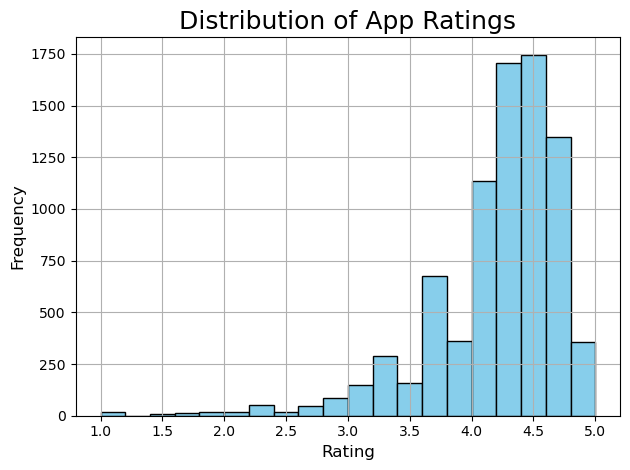

In [17]:
# Calcular el promedio de calificación de las apps
avg_app_rating = apps['Rating'].mean()
print('Average app rating = ', avg_app_rating)

# Calcula el promedio de calificación por categoría
avg_rating_by_category = apps.groupby('Category')['Rating'].mean()

# Visualiza en un histograma el comportamiento del Rating
plt.hist(apps['Rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of App Ratings', fontsize=18)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Size and Price
<p>Examinemos ahora el tamaño y el precio de la aplicación. En cuanto al tamaño, si la aplicación móvil es demasiado grande, puede ser difícil y/o costoso para los usuarios descargarla. Los tiempos de descarga prolongados pueden desanimar a los usuarios incluso antes de que experimenten su aplicación móvil. Además, el dispositivo de cada usuario tiene una cantidad limitada de espacio en disco. Por el precio, algunos usuarios esperan que sus aplicaciones sean gratuitas o económicas. Estos problemas se agravan si el mercado objetivo es en países en vías de desarrollo; especialmente debido a las velocidades de Internet, el poder adquisitivo, los tipos de cambio, etc.</p>
<p>How can we effectively come up with strategies to size and price our app?</p>
<ul>
<li>¿El tamaño de una aplicación afecta su calificación?</li>
<li>¿Los usuarios realmente se preocupan por las aplicaciones pesadas del sistema o prefieren las aplicaciones ligeras? </li>
<li>¿El precio de una aplicación afecta su calificación? </li>
<li>¿Los usuarios siempre prefieren las aplicaciones gratuitas a las de paga?</li>
</ul>

Correlación entre el tamaño de la aplicación y la calificación: 0.078

Promedio de tamaño por categoría (top categorías):
Category
GAME               42.879327
FAMILY             28.974735
MEDICAL            18.909774
FINANCE            17.964729
LIFESTYLE          15.508550
PERSONALIZATION    11.544203
TOOLS               8.299361
Name: Size, dtype: float64

Promedio de calificación por categoría (top categorías):
Category
PERSONALIZATION    4.325362
GAME               4.235697
FAMILY             4.179497
MEDICAL            4.162406
FINANCE            4.104651
LIFESTYLE          4.089963
TOOLS              4.005911
Name: Rating, dtype: float64

Correlación entre el precio de la aplicación y la calificación: -0.112

Promedio de precio de las aplicaciones de paga: 15.24
Promedio de calificación de las aplicaciones de paga: 4.24


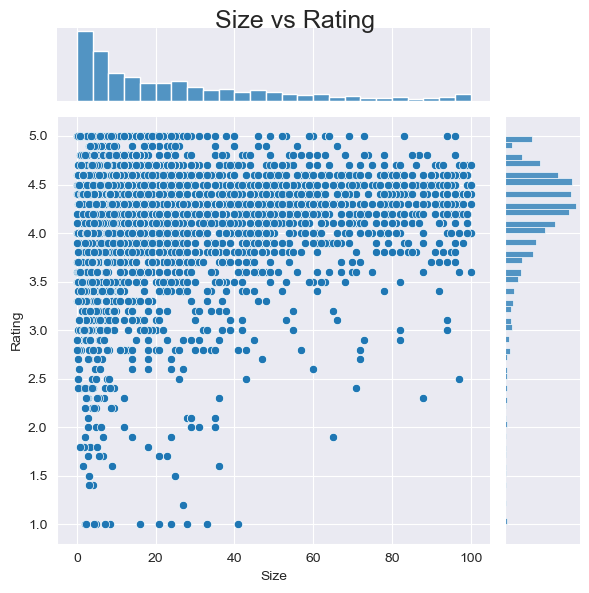

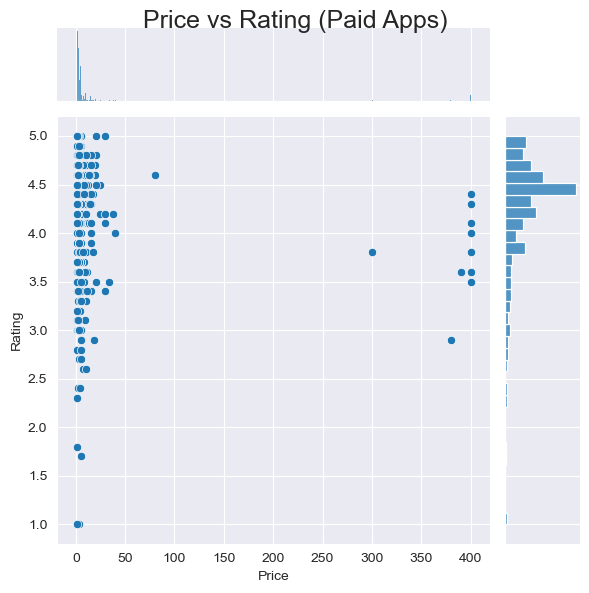

In [23]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("darkgrid")

# Filtra filas donde los valores de 'Rating' y 'Size' no sean nulos
apps_with_size_and_rating_present = apps.dropna(subset=['Rating', 'Size'])

# Filtra las categorías con al menos 250 apps
large_categories = apps_with_size_and_rating_present.groupby('Category').filter(lambda x: len(x) >= 250)

# Gráfica size vs. rating
plt1 = sns.jointplot(x='Size', y='Rating', data=large_categories)
plt1.fig.suptitle('Size vs Rating', fontsize=18)
plt1.fig.tight_layout()
plt1.fig.subplots_adjust(top=0.95)  # Ajuste el título

# Resultados textuales para Size vs Rating
size_rating_corr = large_categories[['Size', 'Rating']].corr().iloc[0, 1]
print(f"Correlación entre el tamaño de la aplicación y la calificación: {size_rating_corr:.3f}")

# Analizamos la media de Size y Rating en las categorías con más de 250 apps
avg_size_by_category = large_categories.groupby('Category')['Size'].mean()
avg_rating_by_category = large_categories.groupby('Category')['Rating'].mean()

print("\nPromedio de tamaño por categoría (top categorías):")
print(avg_size_by_category.sort_values(ascending=False).head(10))

print("\nPromedio de calificación por categoría (top categorías):")
print(avg_rating_by_category.sort_values(ascending=False).head(10))

# Selecciona las apps de paga 'Type' = 'Paid'
paid_apps = apps_with_size_and_rating_present[apps_with_size_and_rating_present['Type'] == 'Paid']

# Grafica price vs. rating de las aplicaciones de paga
plt2 = sns.jointplot(x='Price', y='Rating', data=paid_apps)
plt2.fig.suptitle('Price vs Rating (Paid Apps)', fontsize=18)
plt2.fig.tight_layout()
plt2.fig.subplots_adjust(top=0.95)  # Ajuste el título

# Resultados textuales para Price vs Rating
price_rating_corr = paid_apps[['Price', 'Rating']].corr().iloc[0, 1]
print(f"\nCorrelación entre el precio de la aplicación y la calificación: {price_rating_corr:.3f}")

# Analizamos la media de Price y Rating para las aplicaciones de paga
avg_price_paid_apps = paid_apps['Price'].mean()
avg_rating_paid_apps = paid_apps['Rating'].mean()

print(f"\nPromedio de precio de las aplicaciones de paga: {avg_price_paid_apps:.2f}")
print(f"Promedio de calificación de las aplicaciones de paga: {avg_rating_paid_apps:.2f}")

plt.show()



## 6. Relation between Category & Price
<p>Así que ahora viene la parte difícil. ¿Cómo se supone que las empresas y los desarrolladores cubran sus cuotas de fin de mes? ¿Qué estrategias de monetización pueden utilizar las empresas para maximizar las ganancias? Los costos de las aplicaciones se basan en gran medida en las características, la complejidad y la plataforma. Hay muchos factores a considerar al seleccionar la estrategia de precios adecuada para las aplicaciones moviles. Es importante considerar la disposición de su cliente a pagar por la aplicación. Un precio elevado puede hacer que los clientes no se vean atraídos por descargarlaque ocurra la descarga o pueden eliminar una aplicación que han descargado después de recibir demasiados anuncios o simplemente no obtener el valor que esperaban de su dinero.</p>

<p>Las diferentes categorías exigen diferentes rangos de precios. Algunas aplicaciones que son simples y se usan a diario, como la aplicación de calculadora, probablemente deberían mantenerse gratuitas. Sin embargo, tendría sentido cobrar por una aplicación médica altamente especializada que diagnostica a pacientes diabéticos, así que vamos a descubrir y encontrar la respuesta</p>

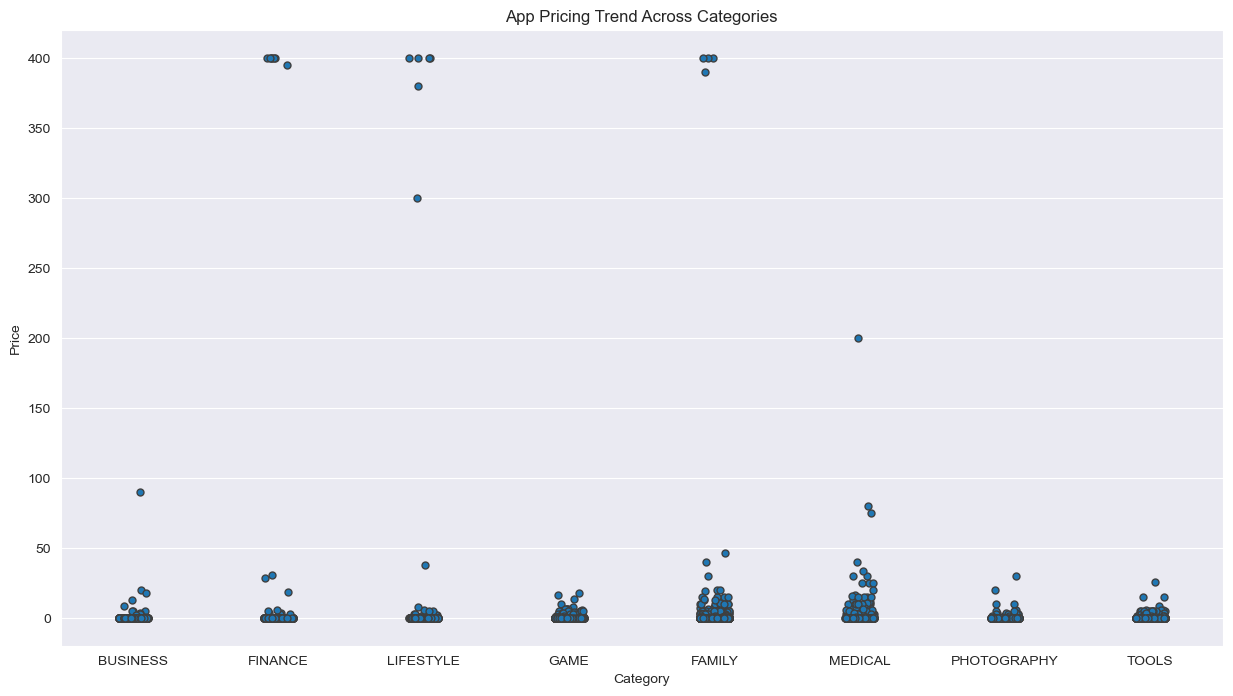

       Category                                App   Price
3327     FAMILY             most expensive app (H)  399.99
3465  LIFESTYLE                         💎 I'm rich  399.99
3469  LIFESTYLE           I'm Rich - Trump Edition  400.00
4396  LIFESTYLE                          I am rich  399.99
4398     FAMILY                     I am Rich Plus  399.99
4399  LIFESTYLE                      I am rich VIP  299.99
4400    FINANCE                  I Am Rich Premium  399.99
4401  LIFESTYLE                I am extremely Rich  379.99
4402    FINANCE                         I am Rich!  399.99
4403    FINANCE                 I am rich(premium)  399.99
4406     FAMILY                      I Am Rich Pro  399.99
4408    FINANCE     I am rich (Most expensive app)  399.99
4410     FAMILY                          I Am Rich  389.99
4413    FINANCE                          I am Rich  399.99
4417    FINANCE                 I AM RICH PRO PLUS  399.99
8763    FINANCE                        Eu Sou Rico  394.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

# Lista de categorías populares
popular_app_cats = apps[apps['Category'].isin(['GAME', 'FAMILY', 'PHOTOGRAPHY',
                                                'MEDICAL', 'TOOLS', 'FINANCE',
                                                'LIFESTYLE', 'BUSINESS'])]

# Examina la tendencia de precio graficando el Precio por Categoría
ax = sns.stripplot(x = popular_app_cats['Category'], y = popular_app_cats['Price'], jitter=True, linewidth=1)
ax.set_title('App Pricing Trend Across Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Price')

plt.show()

# Selecciona las apps con un precio mayor a 200
apps_above_200 = apps[apps['Price'] > 200]
print(apps_above_200[['Category', 'App', 'Price']])


In [27]:
# Filtramos las apps con un precio mayor a 200 (ya las tienes definidas en 'apps_above_200')
apps_above_200 = apps[apps['Price'] > 200]

# Calculamos la relación precio/calificación (precio / calificación)
apps_above_200['Price_to_Rating'] = apps_above_200['Price'] / apps_above_200['Rating']

# Ordenamos las apps por la mejor relación precio/calificación (más baja)
apps_above_200_sorted = apps_above_200.sort_values(by='Price_to_Rating')

# Mostramos las aplicaciones con mejor relación costo/calificación
best_value_apps = apps_above_200_sorted[['Category', 'App', 'Price', 'Rating', 'Price_to_Rating']]

# Mostrar las aplicaciones con mejor relación precio/calificación
print(best_value_apps.head(10))  # Muestra las 10 primeras


       Category                             App   Price  Rating  \
4399  LIFESTYLE                   I am rich VIP  299.99     3.8   
4406     FAMILY                   I Am Rich Pro  399.99     4.4   
3327     FAMILY          most expensive app (H)  399.99     4.3   
4413    FINANCE                       I am Rich  399.99     4.3   
4400    FINANCE               I Am Rich Premium  399.99     4.1   
4408    FINANCE  I am rich (Most expensive app)  399.99     4.1   
4398     FAMILY                  I am Rich Plus  399.99     4.0   
4417    FINANCE              I AM RICH PRO PLUS  399.99     4.0   
3465  LIFESTYLE                      💎 I'm rich  399.99     3.8   
4396  LIFESTYLE                       I am rich  399.99     3.8   

      Price_to_Rating  
4399        78.944737  
4406        90.906818  
3327        93.020930  
4413        93.020930  
4400        97.558537  
4408        97.558537  
4398        99.997500  
4417        99.997500  
3465       105.260526  
4396       105.260526 

In [31]:
import pandas as pd

# Asumimos que tienes un DataFrame llamado 'apps' con las columnas: 'Category', 'App', 'Price', 'Rating'

# 1. Mejor calificación y mayor precio
best_rating_highest_price = apps.sort_values(by=['Rating', 'Price'], ascending=[False, False])

# 2. Mejor calificación y menor precio
best_rating_lowest_price = apps.sort_values(by=['Rating', 'Price'], ascending=[False, True])

# 3. Mejor calificación y gratuitas (Precio = 0)
best_rating_free = apps[apps['Price'] == 0].sort_values(by='Rating', ascending=False)

# Mostrar los resultados (top 5 de cada lista)
print("Mejor calificadas y más caras:")
print(best_rating_highest_price[['Category', 'App', 'Price', 'Rating']].head())  # Top 5
print("\nMejor calificadas y más baratas:")
print(best_rating_lowest_price[['Category', 'App', 'Price', 'Rating']].head())  # Top 5
print("\nMejor calificadas y gratuitas:")
print(best_rating_free[['Category', 'App', 'Price', 'Rating']].head())  #


Mejor calificadas y más caras:
     Category                                        App  Price  Rating
4525   FAMILY                  AP Art History Flashcards  29.99     5.0
6428   FAMILY                 USMLE Step 2 CK Flashcards  19.99     5.0
4292   FAMILY                      Hey AJ! It's Bedtime!   4.99     5.0
4518   FAMILY                 meStudying: AP English Lit   4.99     5.0
6160   FAMILY  TI-84 CE Graphing Calculator Manual TI 84   4.99     5.0

Mejor calificadas y más baratas:
    Category                                         App  Price  Rating
293   COMICS                Hojiboy Tojiboyev Life Hacks    0.0     5.0
511   DATING               American Girls Mobile Numbers    0.0     5.0
514   DATING                                Awake Dating    0.0     5.0
532   DATING                       Spine- The dating app    0.0     5.0
535   DATING  Girls Live Talk - Free Text and Video Chat    0.0     5.0

Mejor calificadas y gratuitas:
                Category               

## 7. Paid apps vs Free apps
<p>Para las aplicaciones de Play Store en la actualidad, existen cinco tipos de estrategias de precios: gratis, "freemium", de pago, "paymium" y de suscripción. Centrémonos solo en aplicaciones gratuitas y de pago. 

Algunas características de las aplicaciones gratuitas son:</p>
<ul>
<li>Libres de descarga.</li>
<li>La principal fuente de ingresos a menudo proviene de la publicidad.</li>
<li>Por lo general son creadaa por empresas que tienen otros productos y la aplicación sirve como una extensión de esos productos.</li>
<li>Puede servir como una herramienta para la retención de clientes, la comunicación y el servicio al cliente.</li>
</ul>
<p>Algunas características de las aplicaciones de paga son:</p>
<ul>
<li>Tienen un tiempo de servicio de prueba gratuito, esto para que el usuario pueda conocerla.</li>
<li>Ofrecen un servicio de mayor especialidad.</li>
</ul>
<p>¿Además de esto que otras características diferencías a las aplicaciones de pago las aplicaciones gratuitas?</p>

## Diferencias entre aplicaciones gratuitas y de pago:

#### Soporte más directo:
Las apps de pago suelen ofrecer un soporte al cliente más personalizado y rápido.
#### Contenido exclusivo: 
Acceso a funciones o contenido especial que no está disponible en la versión gratuita.
#### Funciones desbloqueadas:
Las versiones de pago suelen tener más herramientas y opciones disponibles.
#### Sin publicidad:
Las apps de pago generalmente no tienen anuncios, o los limitan significativamente en comparación con las versiones gratuitas.

## 8. Sentiment analysis
<p>La minería de datos de reseñas de usuarios para determinar cómo se sienten las personas acerca de su producto, marca o servicio se puede realizar mediante una técnica llamada análisis de sentimientos. Las reseñas de los usuarios de las aplicaciones se pueden analizar para identificar si el estado de ánimo es positivo, negativo o neutral con respecto a esa aplicación. Por ejemplo, las palabras positivas en la revisión de una aplicación pueden incluir palabras como "asombroso", "amigable", "bueno", "excelente" y "amor". Las palabras negativas pueden ser palabras como 'malware', 'odio', 'problema', 'reembolso' e 'incompetente'.</p>

<p>¿Qué podemos decir acerca del analisis de sentimiento de las aplicaciones?</p>

Estadísticas de Polaridad de Sentimientos por Tipo de Aplicación:
      count unique       top   freq
Type                               
Free  35513      3  Positive  22748
Paid    416      3  Positive    325


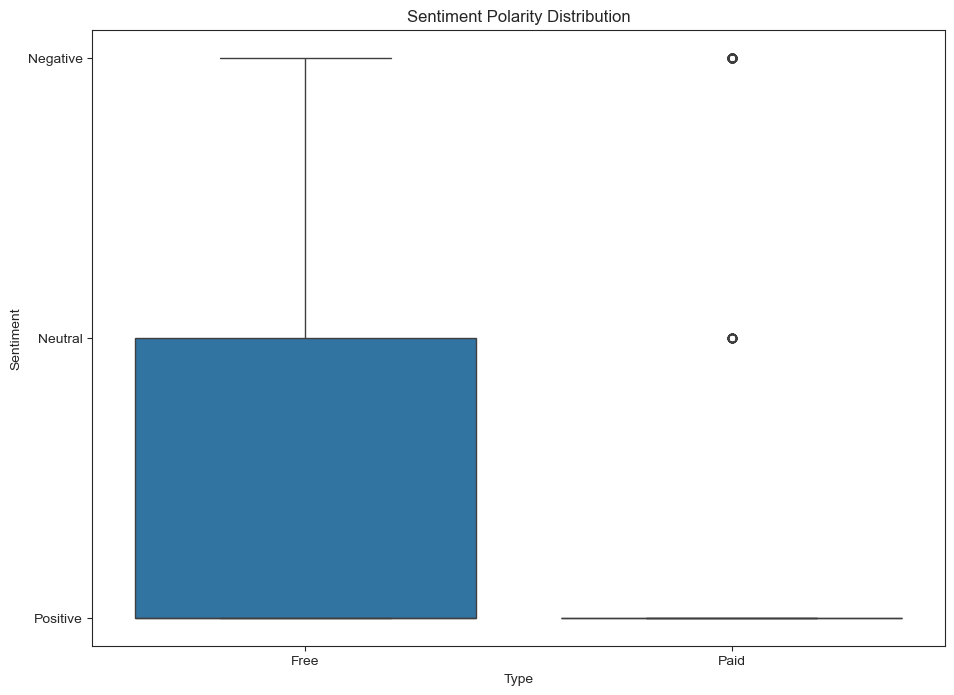

In [37]:
# Carga el archivo de reseñas de usuarios
reviews_df = pd.read_csv('user_reviews.csv')

# Une los DataFrames de aplicaciones con las reseñas (asegurándose de que haya una columna común, como 'App')
merged_df = pd.merge(apps, reviews_df, on='App', how='inner')

# Elimina los valores nulos (NA) en las columnas 'Sentiment' y 'Review'
merged_df = merged_df.dropna(subset=['Sentiment', 'Review'])

# Generar estadísticas descriptivas de polaridad de sentimientos por tipo de aplicación
sentiment_stats = merged_df.groupby('Type')['Sentiment'].describe()

# Imprimir estadísticas resumidas de polaridad de sentimientos
print("Estadísticas de Polaridad de Sentimientos por Tipo de Aplicación:")
print(sentiment_stats)

# Grafica la polaridad de sentimientos para aplicaciones gratuitas y de pago
sns.set_style('ticks')
fig, ax = plt.subplots()
fig.set_size_inches(11, 8)

ax = sns.boxplot(x='Type', y='Sentiment', data=merged_df)
ax.set_title('Sentiment Polarity Distribution')
plt.show()


Cantidad de Apps de Paga por Sentimiento:
Sentiment
Positive    325
Negative     63
Neutral      28
Name: count, dtype: int64

Cantidad de Apps Gratuitas por Sentimiento:
Sentiment
Positive    22748
Negative     7942
Neutral      4823
Name: count, dtype: int64


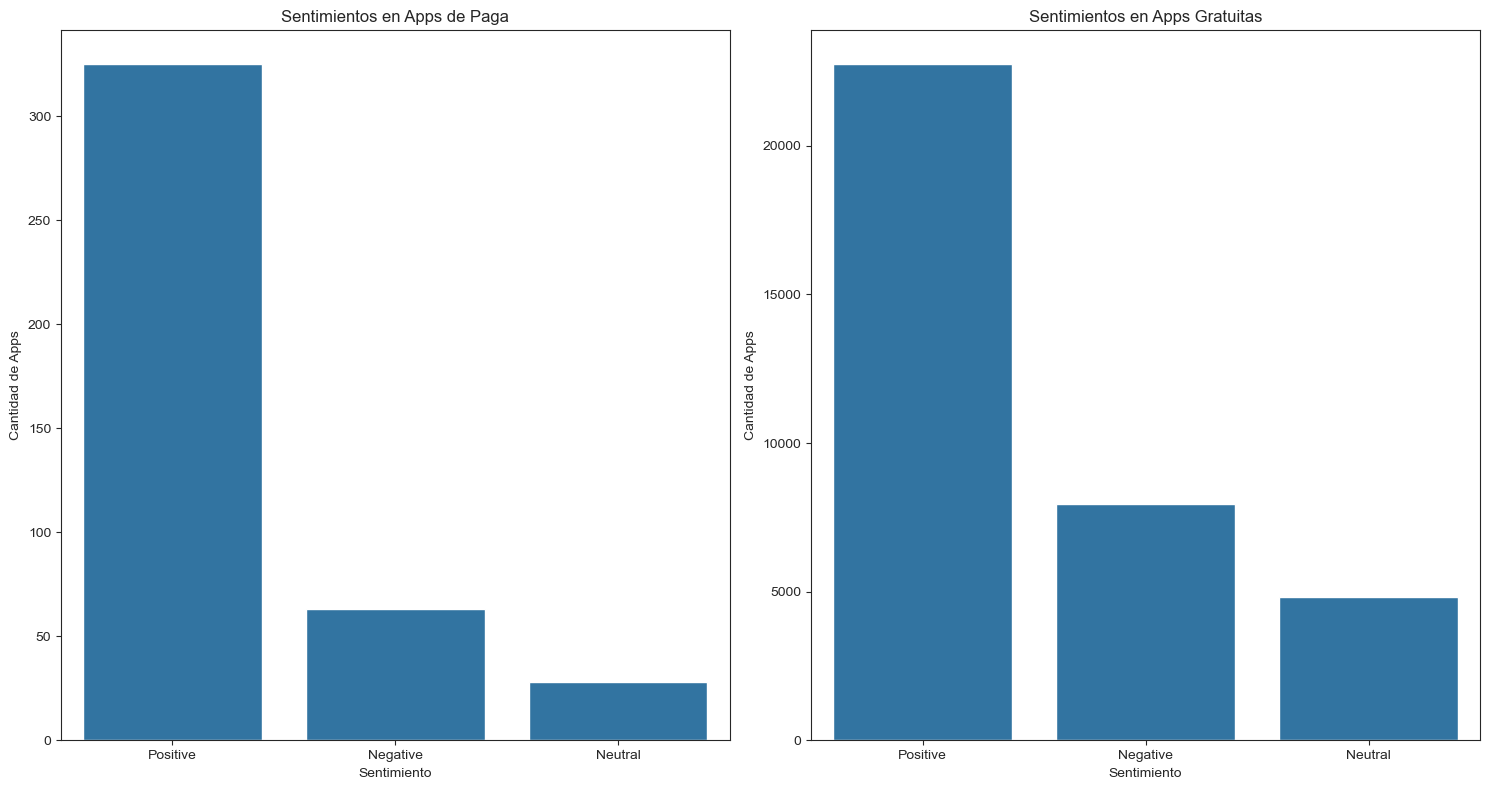

In [39]:
# Contar la cantidad de apps de pago con sentimientos positivos, neutrales y negativos
paid_sentiment_counts = merged_df[merged_df['Type'] == 'Paid']['Sentiment'].value_counts()

# Contar la cantidad de apps gratuitas con sentimientos positivos, neutrales y negativos
free_sentiment_counts = merged_df[merged_df['Type'] == 'Free']['Sentiment'].value_counts()

# Mostrar los resultados en texto para apps de pago
print("Cantidad de Apps de Paga por Sentimiento:")
print(paid_sentiment_counts)

# Mostrar los resultados en texto para apps gratuitas
print("\nCantidad de Apps Gratuitas por Sentimiento:")
print(free_sentiment_counts)

# Graficar los resultados
sns.set_style('ticks')
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

# Graficar los sentimientos de las apps de paga
sns.barplot(x=paid_sentiment_counts.index, y=paid_sentiment_counts.values, ax=ax[0])
ax[0].set_title('Sentimientos en Apps de Paga')
ax[0].set_xlabel('Sentimiento')
ax[0].set_ylabel('Cantidad de Apps')

# Graficar los sentimientos de las apps gratuitas
sns.barplot(x=free_sentiment_counts.index, y=free_sentiment_counts.values, ax=ax[1])
ax[1].set_title('Sentimientos en Apps Gratuitas')
ax[1].set_xlabel('Sentimiento')
ax[1].set_ylabel('Cantidad de Apps')

plt.tight_layout()
plt.show()


In [43]:
pip install wordcloud


   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   -- ------------------------------------ 20.5/301.2 kB 640.0 kB/s eta 0:00:01
   --- ----------------------------------- 30.7/301.2 kB 435.7 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/301.2 kB 393.8 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/301.2 kB 819.2 kB/s eta 0:00:01
   ------------------------- -------------- 194.6/301.2 kB 1.1 MB/s eta 0:00:01
   ------------------------------------ --- 276.5/301.2 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 301.2/301.2 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Resumen de aplicaciones con reseñas negativas:
                                           App        Category  Price  Type  \
0                          Coloring book moana  ART_AND_DESIGN    0.0  Free   
62                        Garden Coloring Book  ART_AND_DESIGN    0.0  Free   
239  Boys Photo Editor - Six Pack & Men's Suit  ART_AND_DESIGN    0.0  Free   
279              Colorfit - Drawing & Coloring  ART_AND_DESIGN    0.0  Free   
326                      Animated Photo Editor  ART_AND_DESIGN    0.0  Free   

     Size  Rating  
0    14.0     3.9  
62   33.0     4.4  
239  12.0     4.1  
279  25.0     4.7  
326   6.1     4.1  


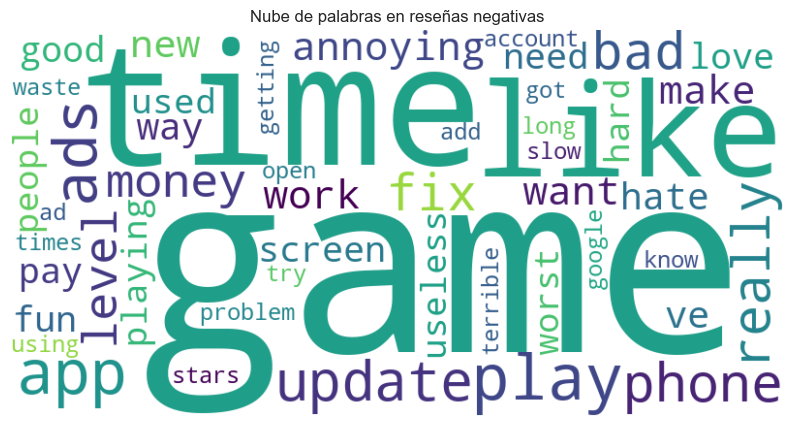

Correlación entre características y reseñas negativas:
          Price      Size    Rating
Price   1.00000 -0.036240 -0.000520
Size   -0.03624  1.000000  0.261409
Rating -0.00052  0.261409  1.000000


In [45]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Filtrar aplicaciones con sentimiento negativo
negative_apps = merged_df[merged_df['Sentiment'] == 'Negative']

# Examinar algunas características de las aplicaciones con más reseñas negativas
negative_apps_summary = negative_apps[['App', 'Category', 'Price', 'Type', 'Size', 'Rating']].drop_duplicates()

# Ver las categorías más comunes entre las apps con reseñas negativas
category_count = negative_apps['Category'].value_counts()

# Mostrar resumen de las apps con reseñas negativas
print("Resumen de aplicaciones con reseñas negativas:")
print(negative_apps_summary.head())

# Analizar las palabras más comunes en las reseñas negativas
vectorizer = CountVectorizer(stop_words='english', max_features=50)  # Usamos el parámetro max_features para obtener las 50 palabras más comunes
negative_reviews = negative_apps['Review'].values
X = vectorizer.fit_transform(negative_reviews)
words = vectorizer.get_feature_names_out()

# Crear una nube de palabras con las palabras más comunes
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(words, X.sum(axis=0).tolist()[0])))

# Mostrar la nube de palabras
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras en reseñas negativas')
plt.show()

# Correlación entre las características y las reseñas negativas
# Podemos ver la correlación entre la calificación, el precio, y otras variables
negative_apps_corr = negative_apps[['Price', 'Size', 'Rating']].corr()

# Mostrar la correlación
print("Correlación entre características y reseñas negativas:")
print(negative_apps_corr)


Palabras más comunes en reseñas negativas:
      Word  Frequency
22    game       4272
77    time       1414
41    like       1258
60    play        942
5      app        924
3      ads        862
83  update        743
59   phone        696
63  really        668
6      bad        646


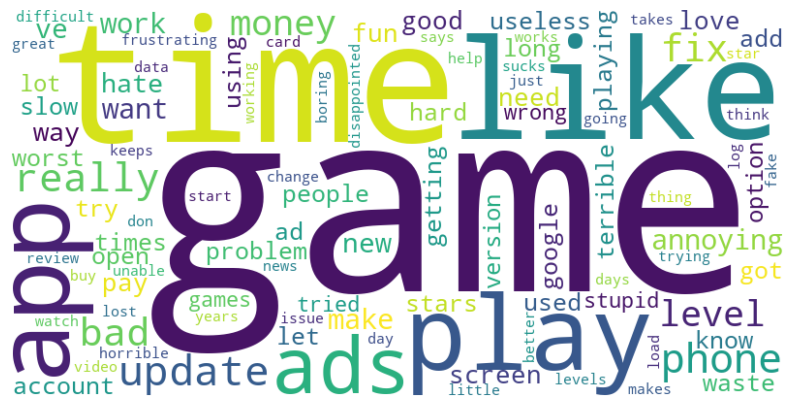

In [49]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtrar reseñas negativas
negative_reviews = merged_df[merged_df['Sentiment'] == 'Negative']['Review']

# Preprocesar el texto para eliminar palabras comunes (stopwords)
vectorizer = CountVectorizer(stop_words='english', max_features=100)
word_counts = vectorizer.fit_transform(negative_reviews)

# Obtener las palabras más comunes
word_freq = word_counts.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Crear un DataFrame con las palabras y su frecuencia
word_freq_df = pd.DataFrame({'Word': words, 'Frequency': word_freq})

# Ordenar las palabras por frecuencia
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

# Mostrar las palabras más comunes
print("Palabras más comunes en reseñas negativas:")
print(word_freq_df.head(10))

# Crear la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(words, word_freq)))

# Mostrar la nube de palabras
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


Palabras más comunes (sin las palabras excluidas) en reseñas negativas:
        Word  Frequency
3        ads        862
83    update        743
19       fix        622
51     money        550
39     level        547
4   annoying        536
90      want        534
49      make        531
94      work        528
53       new        502


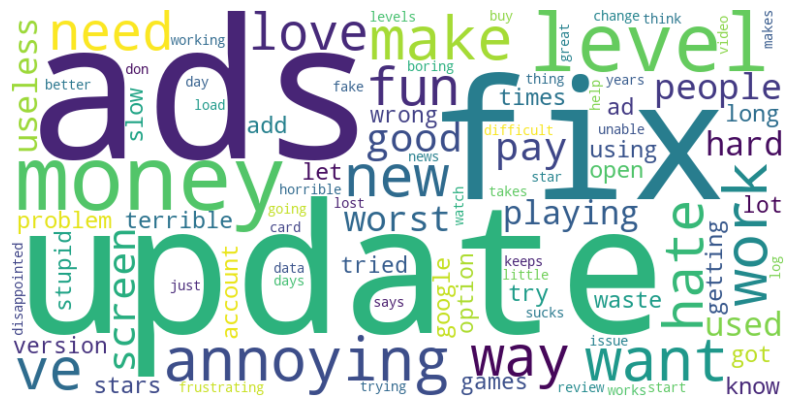

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar reseñas negativas
negative_reviews = merged_df[merged_df['Sentiment'] == 'Negative']['Review']

# Preprocesar el texto para eliminar palabras comunes (stopwords)
vectorizer = CountVectorizer(stop_words='english', max_features=100)
word_counts = vectorizer.fit_transform(negative_reviews)

# Obtener las palabras más comunes
word_freq = word_counts.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Crear un DataFrame con las palabras y su frecuencia
word_freq_df = pd.DataFrame({'Word': words, 'Frequency': word_freq})

# Filtrar las palabras específicas que no queremos ver
excluded_words = ['game', 'time', 'like', 'play', 'app', 'phone', 'really', 'bad']
filtered_word_freq_df = word_freq_df[~word_freq_df['Word'].isin(excluded_words)]

# Ordenar las palabras por frecuencia
filtered_word_freq_df = filtered_word_freq_df.sort_values(by='Frequency', ascending=False)

# Mostrar las palabras más comunes restantes
print("Palabras más comunes (sin las palabras excluidas) en reseñas negativas:")
print(filtered_word_freq_df.head(10))

# Crear la nube de palabras filtrada
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(
    dict(zip(filtered_word_freq_df['Word'], filtered_word_freq_df['Frequency'])))

# Mostrar la nube de palabras
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [61]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to C:\Users\Rod
[nltk_data]     Cissan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [67]:
pip install textblob
!pip install textblob

SyntaxError: invalid syntax (3323493391.py, line 1)

In [69]:
!pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
   -- ------------------------------------ 41.0/624.3 kB 393.8 kB/s eta 0:00:02
   ----- --------------------------------- 92.2/624.3 kB 751.6 kB/s eta 0:00:01
   ----------- ---------------------------- 184.3/624.3 kB 1.1 MB/s eta 0:00:01
   ------------------ --------------------- 286.7/624.3 kB 1.4 MB/s eta 0:00:01
   -------------------------------- ------- 512.0/624.3 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ----------------- ---------------------- 0.6/1.5 MB 20.5 MB/s eta 0:00:01
   ----------------------------- ---------- 1.1/1.5 MB 17.4 MB/s eta 0:00:01
   ---------------------------------------  1.5/1.5 MB 15.9 MB/s eta 0:00:01
   --

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from nltk.corpus import stopwords
import string

# Cargar datos de reseñas
reviews_df = pd.read_csv('user_reviews.csv')

import string
from nltk.corpus import stopwords

def preprocess_text(text):
    if isinstance(text, str):  # Verifica que el valor sea una cadena
        # Convertir a minúsculas, eliminar signos de puntuación y stopwords
        stop_words = set(stopwords.words('english'))
        text = text.lower()  # Convertir a minúsculas
        text = ''.join([char for char in text if char not in string.punctuation])  # Eliminar puntuación
        text = ' '.join([word for word in text.split() if word not in stop_words])  # Eliminar stopwords
        return text
    return ""  # Si no es un texto válido, retornar una cadena vacía

# Aplicar la función de preprocesamiento a la columna de reseñas
reviews_df['cleaned_review'] = reviews_df['Review'].apply(preprocess_text)

# Agrupar reseñas por app (suponiendo que hay una columna 'App' que indica la app de cada reseña)
grouped_reviews = reviews_df.groupby('App')['cleaned_review'].apply(' '.join).reset_index()

# Análisis de términos más frecuentes por aplicación utilizando TF-IDF
vectorizer = TfidfVectorizer(max_features=10)  # Limitar a las 10 palabras más importantes
X = vectorizer.fit_transform(grouped_reviews['cleaned_review'])

# Obtener términos más frecuentes por app
terms = vectorizer.get_feature_names_out()
app_terms_df = pd.DataFrame(X.toarray(), columns=terms, index=grouped_reviews['App'])

# Mostrar los términos más importantes para cada app
print(app_terms_df)

# Análisis de sentimientos (puede usar librerías como TextBlob o VADER para análisis de sentimientos)
from textblob import TextBlob

# Función para obtener el sentimiento de la reseña
def get_sentiment(text):
    analysis = TextBlob(text)
    # Devuelve 'Positive', 'Negative', o 'Neutral'
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Aplicar análisis de sentimientos a las reseñas agrupadas
grouped_reviews['sentiment'] = grouped_reviews['cleaned_review'].apply(get_sentiment)

# Mostrar los resultados de sentimiento por app
print(grouped_reviews[['App', 'sentiment']].groupby('sentiment').count())



                                                     app      cant      game  \
App                                                                            
10 Best Foods for You                           0.262784  0.094727  0.000000   
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室                0.419521  0.000000  0.000000   
11st                                            0.729261  0.262880  0.000000   
1800 Contacts - Lens Store                      0.559107  0.000000  0.000000   
1LINE – One Line with One Touch                 0.000000  0.049949  0.963427   
...                                                  ...       ...       ...   
Hotspot Shield Free VPN Proxy & Wi-Fi Security  0.000000  0.000000  0.000000   
Hotstar                                         0.428918  0.198790  0.426033   
Hotwire Hotel & Car Rental App                  0.411774  0.356243  0.000000   
Housing-Real Estate & Property                  0.804708  0.000000  0.000000   
Houzz Interior Design Ideas             

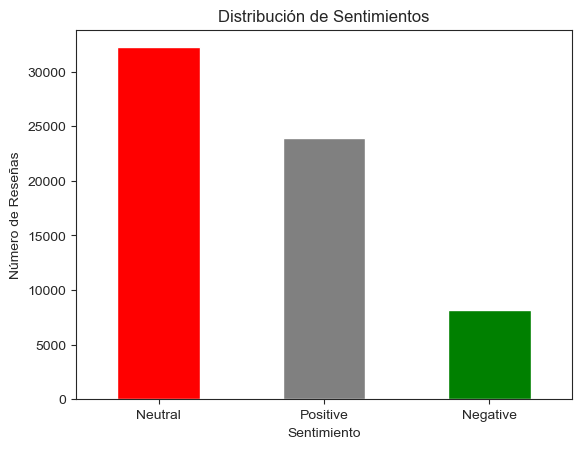

In [77]:
import matplotlib.pyplot as plt
from textblob import TextBlob

# Suponiendo que ya tienes la columna de reseñas (reviews)
def get_sentiment(text):
    analysis = TextBlob(text)
    # Puedes asignar 'positive', 'neutral' o 'negative' dependiendo del resultado
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

# Aplicar la función de análisis de sentimiento
reviews_df['sentiment'] = reviews_df['cleaned_review'].apply(get_sentiment)

# Ahora puedes contar los sentimientos
sentiment_counts = reviews_df['sentiment'].value_counts()

# Mostrar gráfico de barras
sentiment_counts.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Distribución de Sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Número de Reseñas')
plt.xticks(rotation=0)
plt.show()


In [79]:
# Obtener las frecuencias de cada sentimiento
sentiment_counts = reviews_df['sentiment'].value_counts()

# Imprimir los resultados en formato de texto
sentiment_summary = sentiment_counts.to_string()

# Mostrar el resumen
print(sentiment_summary)


sentiment
Neutral     32219
Positive    23924
Negative     8152


## 9. Conclusion
<p>En este cuaderno, analizamos más de diez mil aplicaciones de Google Play Store. Podemos usar nuestros hallazgos para poder encontrar información valiosa por si alguna vez deseamos crear una aplicación nosotros mismos. Espero que hayas disfrutado el curso!!! :)
    
Atte. <a href="https://www.linkedin.com/in/ivan-alducin-a87a71108/">Ivan Alducin</a></p>